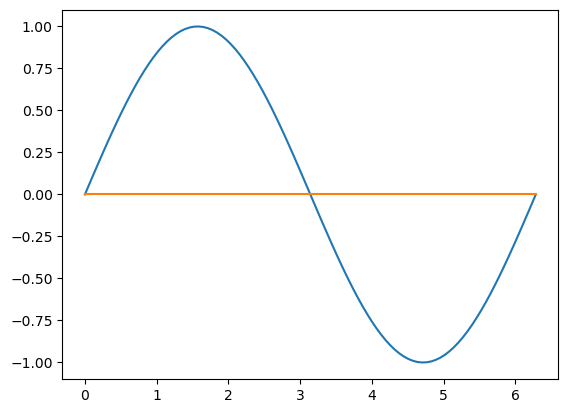

In [1]:
import numpy as np
import matplotlib.pyplot as plt
x_n=np.array([0,2*np.pi])
y_n=np.sin(x_n)
x= np.linspace(0,np.pi*2,100)
y=np.sin(x)
plt.plot(x,y)
plt.plot(x_n,y_n)
plt.show()

In [1]:
import numpy as np

# Sample lists
x = [3, 1, 4, 2]
y = ['three', 'one', 'four', 'two']

# Convert lists to NumPy arrays
x_array = np.array(x)
y_array = np.array(y)

# Get the indices that would sort x_array
sorted_indices = np.argsort(x_array)

# Use the sorted indices to sort both arrays
sorted_x = x_array[sorted_indices]
sorted_y = y_array[sorted_indices]

print("Sorted x:", sorted_x)
print("Sorted y:", sorted_y)


Sorted x: [1 2 3 4]
Sorted y: ['one' 'two' 'three' 'four']


error:  [0.         0.05296388 0.10580095 0.15838472 0.21058932 0.26228986
 0.31336272 0.36368586 0.41313913 0.46160458 0.50896675 0.55511297
 0.59993365 0.64332251 0.68517694 0.72539815 0.76389151 0.80056673
 0.83533813 0.86812482 0.89885092 0.92744578 0.95384408 0.9779861
 0.99981779 1.01929091 1.03636323 1.05099853 1.06316677 1.07284412
 1.08001307 1.08466241 1.08678731 1.0863893  1.08347629 1.07806253
 1.07016861 1.05982134 1.04705375 1.03190498 1.01442017 0.99465038
 0.97265241 0.9484887  0.92222716 0.893941   0.86370852 0.83161297
 0.79774226 0.76218881 0.72504929 0.68642435 0.64641843 0.60513942
 0.56269843 0.51920953 0.4747894  0.42955709 0.3836337  0.33714208
 0.29020649 0.24295235 0.19550584 0.14799367 0.10054268 0.05327957
 0.00633056 0.0401789  0.0861245  0.13138334 0.17583426 0.21935813
 0.26183816 0.3031602  0.34321304 0.38188864 0.41908247 0.45469372
 0.48862558 0.52078549 0.55108534 0.57944175 0.60577621 0.63001535
 0.65209105 0.6719407  0.68950727 0.70473952 0.71759207

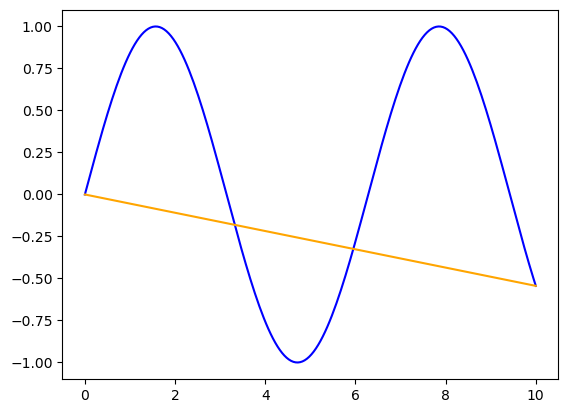

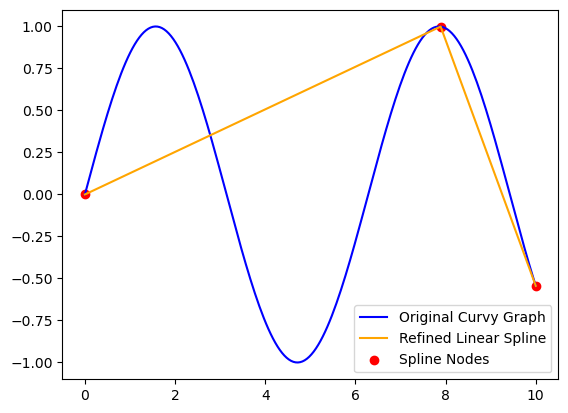

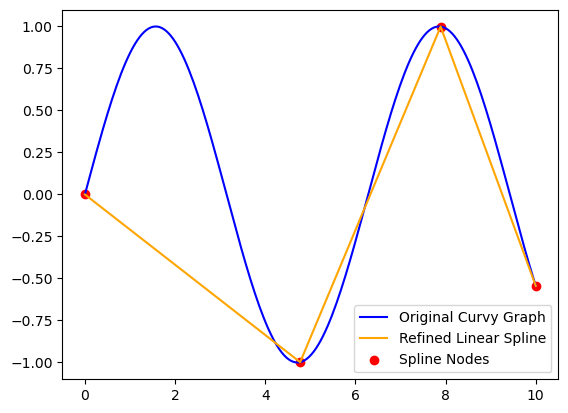

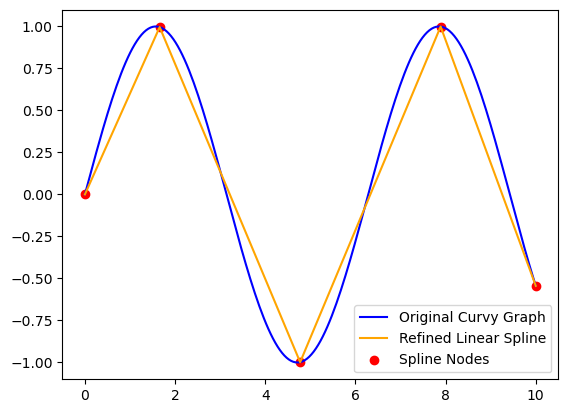

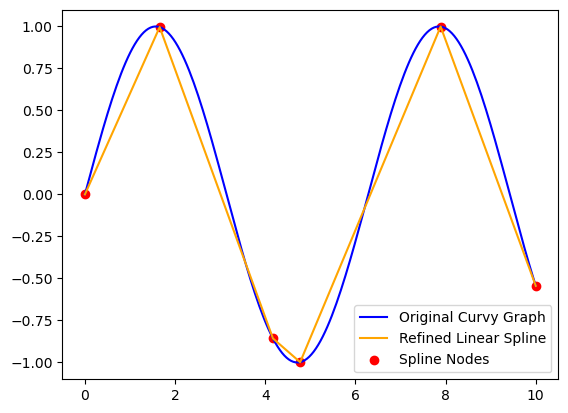

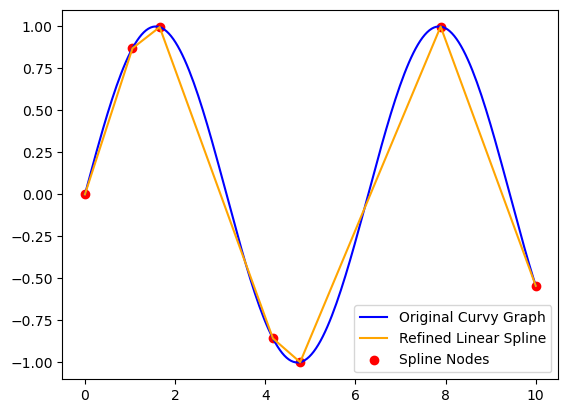

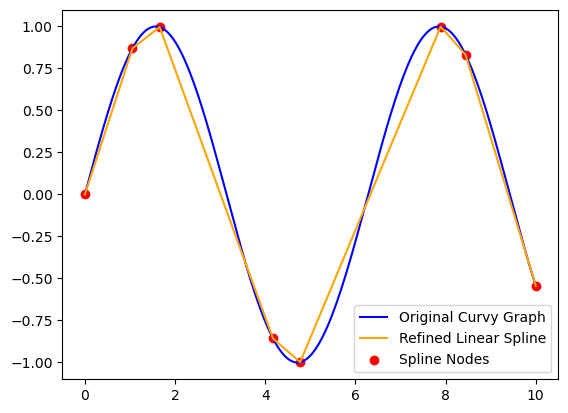

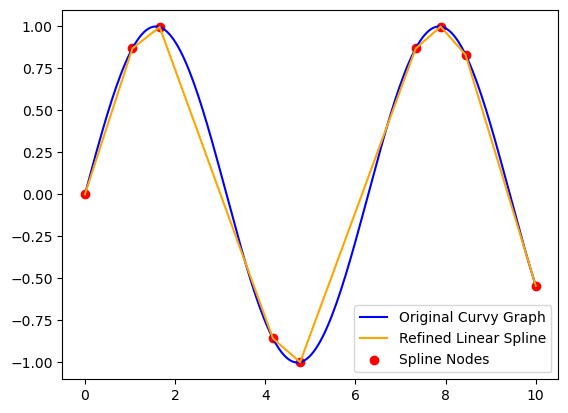

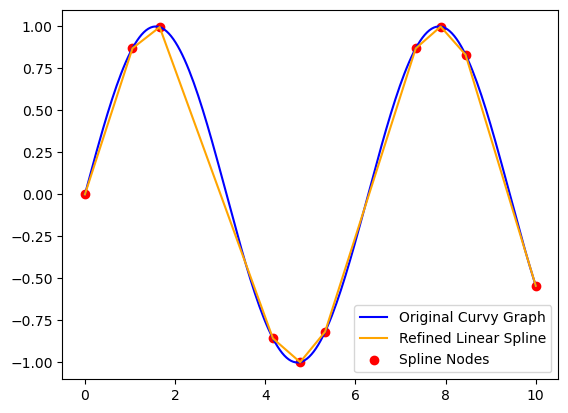

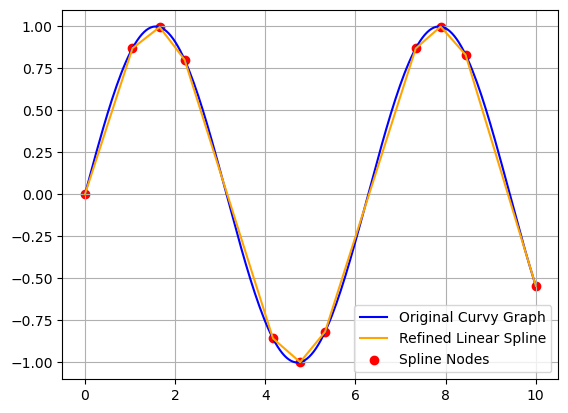

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import os

os.environ["XDG_SESSION_TYPE"] = "xcb"

x = np.linspace(0, 10, 200)
y = np.sin(x) 
#+ 0.2 * np.random.normal(size=x.shape)
# y = np.convolve(y_noise, np.ones(10)/10, mode='same')

# os.environ['QT_QPA_PLATFORM'] = 'wayland'

# def calculate_error(x_original, y_original, spline):
#     y_spline = spline(x_original)
#     error = np.abs(y_original - y_spline)
#     max_error = np.max(error)
#     return max_error, error

def calculate_error(x_original, y_original, spline):
    y_spline = spline(x_original)

    # error = np.sqrt((x_original - x_original)**2 + (y_original - y_spline)**2)
    error = np.abs(y_original - y_spline)
    print("error: ",error)
    max_error = np.max(error)
    return max_error, error

def calculate_curvature(x, y):
    dy = np.gradient(y, x)
    d2y = np.gradient(dy, x)
    curvature = np.abs(d2y)
    return curvature

# Initial critical points (starting with the endpoints)
x_nodes = np.array([0, 10])
y_nodes = np.sin(x_nodes)

threshold_error = 0.08
max_iterations = 12
iteration = 0
curvature = calculate_curvature(x, y)
# interp1d(x_nodes, y_nodes, kind='linear')
while iteration < max_iterations:
    if iteration == 0:
        plt.figure()
        plt.plot(x, y, label='Original Curvy Graph', color='blue')
        plt.plot(x_nodes, y_nodes, label='Initial Linear Spline', color='orange')
    #a linear spline based on current nodes
    linear_spline = interp1d(x_nodes, y_nodes, kind='linear')

    max_error, error = calculate_error(x, y, linear_spline)

    if max_error < threshold_error:
        break

    priority = error * curvature
    max_error_index = np.argmax(priority)
    new_node_x = x[max_error_index]
    new_node_y = y[max_error_index]

    x_nodes = np.sort(np.append(x_nodes, new_node_x))
    y_nodes = np.sin(x_nodes)  # Recalculate y_nodes based on sine function
    # y_nodes = y[np.isin(x, x_nodes)]  # Recalculate y_nodes based on sine function
    # y_nodes =np.sort(np.append(y_nodes, new_node_y))
    iteration += 1
    plt.figure()
    plt.plot(x, y, label='Original Curvy Graph', color='blue')
    plt.plot(x_nodes, y_nodes, label='Refined Linear Spline', color='orange')
    plt.scatter(x_nodes, y_nodes, color='red', label='Spline Nodes')
    plt.legend()

# interp1d(x_nodes, y_nodes, kind='linear')
#a fine grid for plotting the final linear spline
# x_fine = np.linspace(0, 10, 500)
# y_fine = linear_spline(x_fine)


plt.grid()
plt.show()

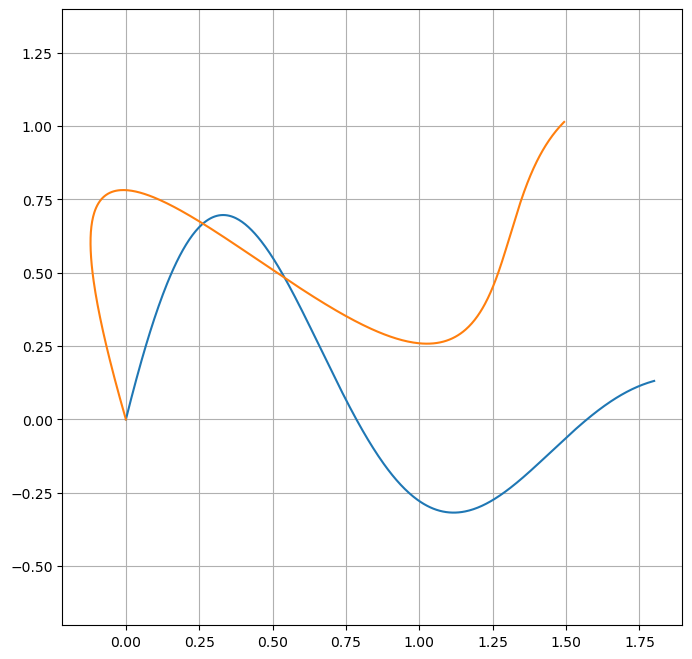

In [8]:
# import matplotlib.pyplot as plt
# import numpy as np

def g(y):
    return np.exp(-y) * np.sin(4 * y)

y = np.linspace(0, 1.8, 501)
values = g(y)

theta = np.radians(30)
c, s = np.cos(theta), np.sin(theta)
rot_matrix = np.array(((c, s), (-s, c)))
xy = np.array([y, values]).T @ rot_matrix

fig, ax = plt.subplots(figsize=(8, 8))

plt.plot(y, values)
plt.plot(xy[:, 0], xy[:, 1])
plt.axis('equal')  # so angles on the screen look like the real angles
plt.grid()
plt.show()


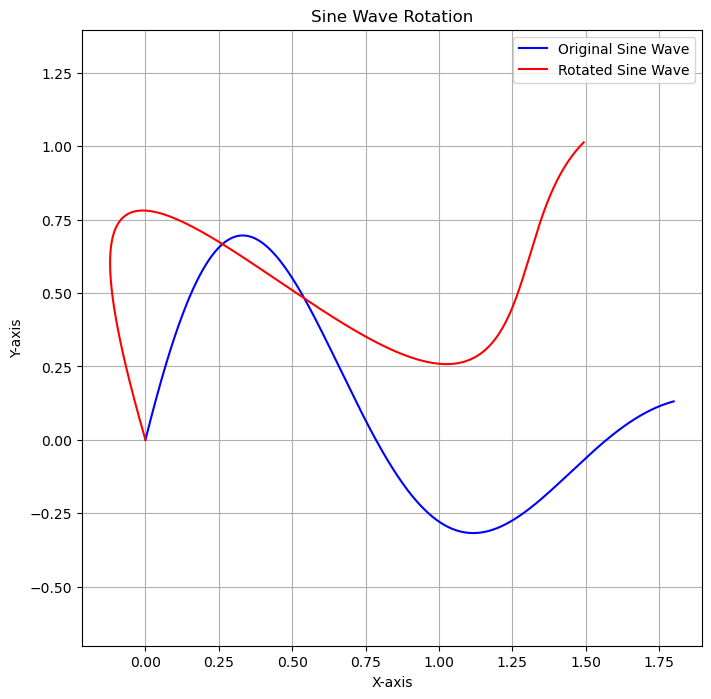

In [11]:
# Define the function for the sine wave
def sine_wave(y):
    return np.exp(-y) * np.sin(4 * y)

# Generate y values
y = np.linspace(0, 1.8, 501)
original_values = sine_wave(y)

# Define the rotation angle in degrees and convert to radians
angle_degrees = 30
angle_radians = np.radians(angle_degrees)

# Create the rotation matrix
cos_angle = np.cos(angle_radians)
sin_angle = np.sin(angle_radians)
rotation_matrix = np.array([[cos_angle, sin_angle], [-sin_angle, cos_angle]])

# Rotate the original sine wave values
points = np.array([y, original_values]).T  # Combine y and sine values into a 2D array
rotated_points = points @ rotation_matrix  # Apply the rotation

# Plotting the original and rotated sine wave
plt.figure(figsize=(8, 8))
plt.plot(y, original_values, label='Original Sine Wave', color='blue')
plt.plot(rotated_points[:, 0], rotated_points[:, 1], label='Rotated Sine Wave', color='red')
plt.axis('equal')  # Ensure equal scaling
plt.title('Sine Wave Rotation')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.grid()
plt.show()


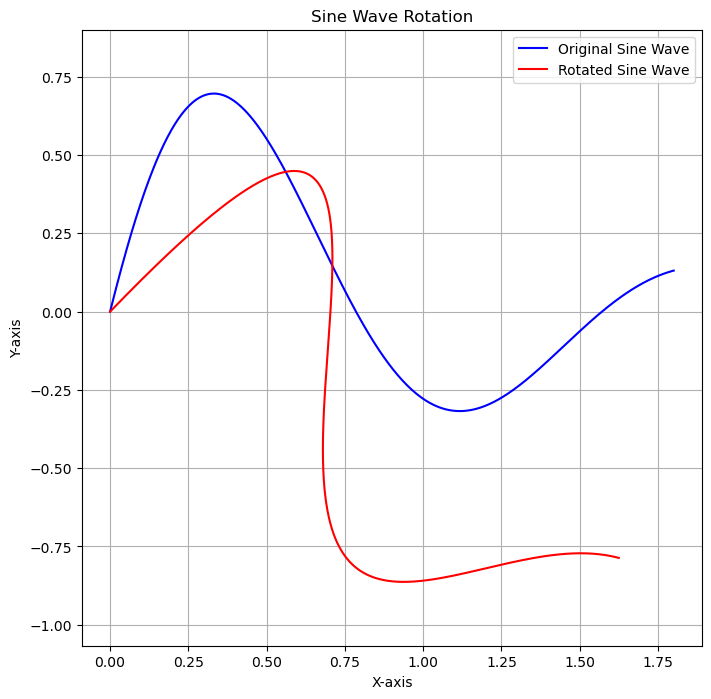

In [4]:
# Define the function for the sine wave
def sine_wave(y):
    return np.exp(-y) * np.sin(4 * y)

# Generate y values
y = np.linspace(0, 1.8, 501)
original_values = sine_wave(y)

# Define the rotation angle in degrees and convert to radians
angle_degrees = 30
angle_radians = np.radians(angle_degrees)

# Calculate cosine and sine of the angle
cos_angle = np.cos(angle_radians)
sin_angle = np.sin(angle_radians)

# Rotate the points without using a matrix
rotated_x = y * cos_angle + original_values * sin_angle
rotated_y = -y * sin_angle + original_values * cos_angle

# Plotting the original and rotated sine wave
plt.figure(figsize=(8, 8))
plt.plot(y, original_values, label='Original Sine Wave', color='blue')
plt.plot(rotated_x, rotated_y, label='Rotated Sine Wave', color='red')
plt.axis('equal')  # Ensure equal scaling
plt.title('Sine Wave Rotation')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.grid()
plt.show()


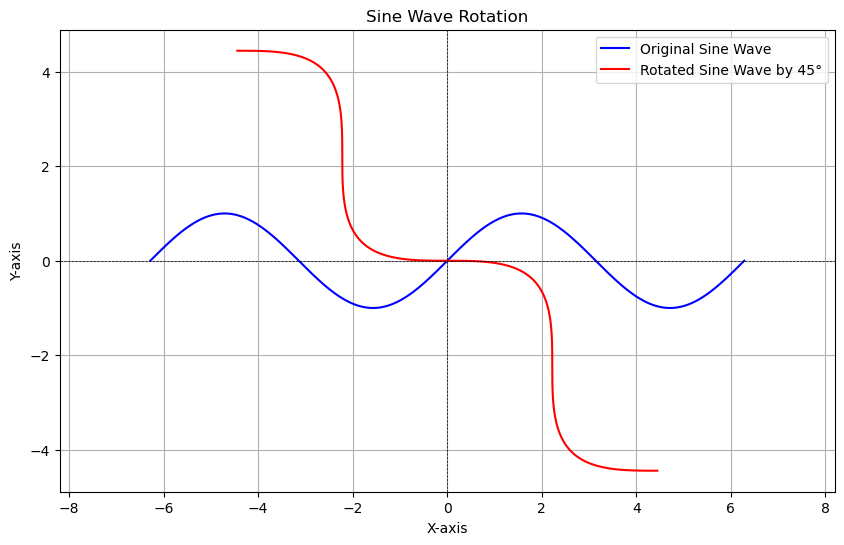

In [12]:
def rotate_point(x, y, theta):
    """Rotate a point (x, y) by angle theta (in radians)."""
    x_rotated = x * np.cos(theta) + y * np.sin(theta)
    y_rotated = -x * np.sin(theta) + y * np.cos(theta)
    return x_rotated, y_rotated

def rotate_sine_wave(x, y, theta):
    """Rotate the sine wave points by angle theta (in radians)."""
    x_rotated, y_rotated = rotate_point(x, y, theta)
    return x_rotated, y_rotated

# Generate sine wave data
x = np.linspace(-2 * np.pi, 2 * np.pi, 1000)
y = np.sin(x)

# Set the rotation angle (in degrees)
angle_degrees = 45  # Change this value to rotate by a different angle
theta = np.radians(angle_degrees)  # Convert to radians

# Rotate the sine wave
x_rotated, y_rotated = rotate_sine_wave(x, y, theta)

# Plot the original and rotated sine wave
plt.figure(figsize=(10, 6))
plt.plot(x, y, label='Original Sine Wave', color='blue')
plt.plot(x_rotated, y_rotated, label=f'Rotated Sine Wave by {angle_degrees}°', color='red')
plt.title('Sine Wave Rotation')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.axhline(0, color='black',linewidth=0.5, ls='--')
plt.axvline(0, color='black',linewidth=0.5, ls='--')
plt.grid()
plt.legend()
plt.axis('equal')
plt.show()


Reduced X: [0.  1.  1.5 3.  5. ]
Reduced Y: [0.  0.5 1.4 0.2 0. ]


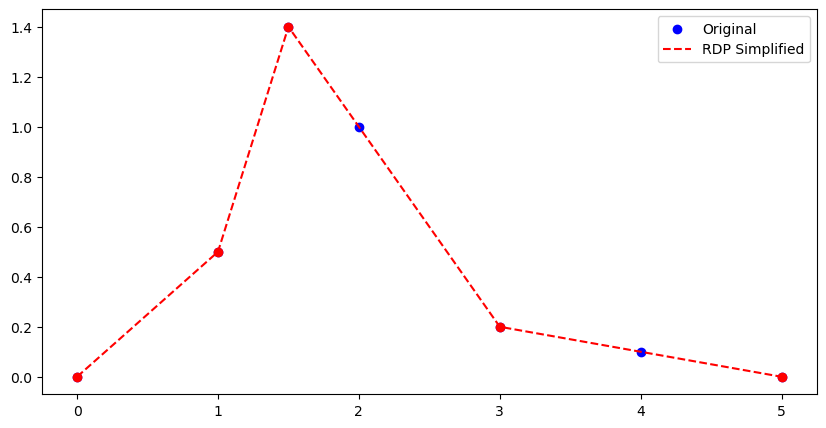

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def perpendicular_distance(point, start, end):
    """Calculate the perpendicular distance of a point from a line segment."""
    if np.all(start == end):
        return np.linalg.norm(point - start)
    
    # Calculate the distance using the cross product method
    return np.abs(np.cross(end - start, start - point) / np.linalg.norm(end - start))

def rdp(x, y, epsilon):
    """
    Recursive implementation of the RDP (Ramer-Douglas-Peucker) algorithm.

    Parameters:
    x (list or np.array): x-coordinates of the points.
    y (list or np.array): y-coordinates of the points.
    epsilon (float): Threshold for the maximum allowed deviation (smaller epsilon results in more points).

    Returns:
    np.array: Reduced set of x, y points.
    """
    if len(x) < 3:
        # If there's no need to simplify, return the original points
        return np.array([x, y])

    # Find the point with the maximum perpendicular distance
    start, end = np.array([x[0], y[0]]), np.array([x[-1], y[-1]])
    max_dist = 0
    index = 0
    for i in range(1, len(x) - 1):
        point = np.array([x[i], y[i]])
        dist = perpendicular_distance(point, start, end)
        if dist > max_dist:
            max_dist = dist
            index = i

    # If the max distance is greater than epsilon, recursively simplify
    if max_dist > epsilon:
        # Recursive call on the first half and second half
        left_x, left_y = rdp(x[:index+1], y[:index+1], epsilon)
        right_x, right_y = rdp(x[index:], y[index:], epsilon)

        # Combine the two halves and remove the duplicate point at the junction
        return np.concatenate((left_x[:-1], right_x)), np.concatenate((left_y[:-1], right_y))
    else:
        # If no point is far enough, return the endpoints
        return np.array([x[0], x[-1]]), np.array([y[0], y[-1]])

# Example usage:
x = np.array([0, 1, 1.5, 2, 3, 4, 5])
y = np.array([0, 0.5, 1.4, 1, 0.2, 0.1, 0])

epsilon = 0.2  # Adjust this for higher/lower tolerance
rdp_x, rdp_y = rdp(x, y, epsilon)

print("Reduced X:", rdp_x)
print("Reduced Y:", rdp_y)

# Visualization
plt.figure(figsize=(10, 5))
plt.scatter(x, y, label="Original", color='blue')
plt.plot(rdp_x, rdp_y, label="RDP Simplified", color='red', linestyle='--')
plt.scatter(rdp_x, rdp_y, color='red', zorder=5)
plt.legend()
plt.show()
